## Célula 1 — Análise Léxica
O Lexer lê o código da DSL caractere por caractere e agrupa em tokens



In [12]:
import matplotlib.pyplot as plt

# --- Definicao dos tipos de token ---
TK_GRAFICO = 'GRAFICO'
TK_BARRA   = 'BARRA'
TK_LINHA   = 'LINHA'
TK_DADOS   = 'DADOS'
TK_TITULO  = 'TITULO'
TK_NUMERO  = 'NUMERO'
TK_TEXTO   = 'TEXTO'
TK_ABRE_P  = 'ABRE_PAREN'
TK_FECHA_P = 'FECHA_PAREN'
TK_VIRGULA = 'VIRGULA'
TK_EOF     = 'EOF'

# --- Classe Token: representa um elemento reconhecido ---
class Token:
    def __init__(self, tipo, valor):
        self.tipo  = tipo
        self.valor = valor
    def __repr__(self):
        return f'Token({self.tipo}, {repr(self.valor)})'

# --- Erros do Lexer ---
class LexerError(Exception):
    pass

# --- Lexer ---
class Lexer:
    # Palavras reservadas da DSL
    RESERVADAS = {
        'GRAFICO': TK_GRAFICO,
        'BARRA':   TK_BARRA,
        'LINHA':   TK_LINHA,
        'DADOS':   TK_DADOS,
        'TITULO':  TK_TITULO,
    }

    def __init__(self, texto):
        self.entrada = texto
        self.pos     = 0
        self.tokens  = []

    def _atual(self):
        # Retorna o caractere atual ou None se chegou ao fim
        return self.entrada[self.pos] if self.pos < len(self.entrada) else None

    def _avanca(self):
        self.pos += 1

    def tokenizar(self):
        while self.pos < len(self.entrada):
            c = self._atual()

            # Ignora espacos e quebras de linha
            if c in (' ', '\t', '\n', '\r'):
                self._avanca()

            # Numero inteiro: sequencia de digitos
            elif c.isdigit():
                inicio = self.pos
                while self._atual() and self._atual().isdigit():
                    self._avanca()
                self.tokens.append(Token(TK_NUMERO, int(self.entrada[inicio:self.pos])))

            # Palavra: verifica se e palavra reservada ou texto livre
            elif c.isalpha() or c == '_':
                inicio = self.pos
                while self._atual() and (self._atual().isalnum() or self._atual() == '_'):
                    self._avanca()
                palavra = self.entrada[inicio:self.pos].upper()
                tipo = self.RESERVADAS.get(palavra, TK_TEXTO)
                self.tokens.append(Token(tipo, palavra))

            # Texto entre aspas duplas
            elif c == '"':
                self._avanca()  # pula a aspa de abertura
                inicio = self.pos
                while self._atual() and self._atual() != '"':
                    self._avanca()
                if self._atual() is None:
                    raise LexerError('Texto nao fechado: falta aspa de fechamento.')
                conteudo = self.entrada[inicio:self.pos]
                self._avanca()  # pula a aspa de fechamento
                self.tokens.append(Token(TK_TEXTO, conteudo))

            elif c == '(':
                self.tokens.append(Token(TK_ABRE_P, '('))
                self._avanca()
            elif c == ')':
                self.tokens.append(Token(TK_FECHA_P, ')'))
                self._avanca()
            elif c == ',':
                self.tokens.append(Token(TK_VIRGULA, ','))
                self._avanca()
            else:
                raise LexerError(f'Caractere desconhecido: {repr(c)}')

        # Marca o fim do arquivo
        self.tokens.append(Token(TK_EOF, None))
        return self.tokens


## Célula 2 — Análise Sintática (Parser)

O Parser pega a lista de tokens e verifica se a sequência segue a gramática BNF

Se a estrutura estiver correta, constrói uma AST


In [13]:
class NoPrograma:
    def __init__(self, comandos):
        self.comandos = comandos

class NoGrafico:
    def __init__(self, tipo, dados, titulo=None):
        self.tipo   = tipo    # 'BARRA' ou 'LINHA'
        self.dados  = dados   # lista de inteiros
        self.titulo = titulo  # string ou None

# --- Erro sintatico ---
class SintaticoError(Exception):
    pass

# --- Parser ---
class Parser:
    def __init__(self, tokens):
        self.tokens = tokens
        self.pos    = 0

    def _atual(self):
        return self.tokens[self.pos]

    def _consumir(self, tipo_esperado):
        """Verifica se o token atual e o esperado e avanca."""
        tok = self._atual()
        if tok.tipo != tipo_esperado:
            raise SintaticoError(
                f'Erro: esperava {tipo_esperado}, mas encontrou {tok.tipo} ({repr(tok.valor)})'
            )
        self.pos += 1
        return tok

    # <programa> ::= <lista-comandos>
    def parse_programa(self):
        comandos = self.parse_lista_comandos()
        self._consumir(TK_EOF)
        return NoPrograma(comandos)

    # <lista-comandos> ::= <comando> | <lista-comandos> <comando>
    def parse_lista_comandos(self):
        comandos = []
        while self._atual().tipo != TK_EOF:
            comandos.append(self.parse_comando())
        return comandos

    # <comando> ::= <grafico>
    def parse_comando(self):
        return self.parse_grafico()

    # <grafico> ::= GRAFICO <tipo-grafico> <dados>
    #             | GRAFICO <tipo-grafico> <dados> <titulo>
    def parse_grafico(self):
        self._consumir(TK_GRAFICO)
        tipo  = self.parse_tipo_grafico()
        dados = self.parse_dados()
        titulo = None
        if self._atual().tipo == TK_TITULO:
            titulo = self.parse_titulo()
        return NoGrafico(tipo, dados, titulo)

    # <tipo-grafico> ::= BARRA | LINHA
    def parse_tipo_grafico(self):
        tok = self._atual()
        if tok.tipo in (TK_BARRA, TK_LINHA):
            self.pos += 1
            return tok.valor
        raise SintaticoError(
            f'Tipo de grafico invalido: {repr(tok.valor)}. Use BARRA ou LINHA.'
        )

    # <dados> ::= DADOS "(" <lista-numeros> ")"
    def parse_dados(self):
        self._consumir(TK_DADOS)
        self._consumir(TK_ABRE_P)
        numeros = self.parse_lista_numeros()
        self._consumir(TK_FECHA_P)
        return numeros

    # <lista-numeros> ::= <numero> | <lista-numeros> "," <numero>
    def parse_lista_numeros(self):
        numeros = [self._consumir(TK_NUMERO).valor]
        while self._atual().tipo == TK_VIRGULA:
            self.pos += 1
            numeros.append(self._consumir(TK_NUMERO).valor)
        return numeros

    # <titulo> ::= TITULO <texto>
    def parse_titulo(self):
        self._consumir(TK_TITULO)
        return self._consumir(TK_TEXTO).valor


## Célula 3 — Análise Semântica

Verifica regras de significadoque a gramática BNF não consegue barrar sozinha.

Regra:
- Valores em DADOS devem ser inteiros positivos (> 0)
- A lista deve ter ao menos 2 valores (1 ponto não gera gráfico útil)
- Tipo LINHA exige ao menos 2 pontos para representar variação
- TITULO, se presente, não pode ser vazio

In [14]:
class SemanticoError(Exception):
    pass

class AnalisadorSemantico:

    def analisar(self, no_programa):
        for i, cmd in enumerate(no_programa.comandos, 1):
            self._verificar(cmd, i)
        print('Analise semantica: APROVADA — nenhum erro encontrado.')

    def _verificar(self, no, indice):
        ctx = f'Grafico {indice} ({no.tipo})'

        # Regra 1: todos os valores devem ser positivos
        for v in no.dados:
            if v <= 0:
                raise SemanticoError(
                    f'{ctx}: valor {v} invalido. Use apenas inteiros positivos.'
                )

        # Regra 2: minimo de 2 valores para qualquer grafico
        if len(no.dados) < 2:
            raise SemanticoError(
                f'{ctx}: informe ao menos 2 valores em DADOS.'
            )

        # Regra 3: LINHA precisa de ao menos 2 pontos
        if no.tipo == 'LINHA' and len(no.dados) < 2:
            raise SemanticoError(
                f'{ctx}: LINHA requer ao menos 2 pontos para representar variacao.'
            )

        # Regra 4: titulo nao pode ser vazio
        if no.titulo is not None and no.titulo.strip() == '':
            raise SemanticoError(
                f'{ctx}: TITULO nao pode ser vazio ou conter apenas espacos.'
            )

## Célula 4 — Interpretador (Geração dos Gráficos)
Percorre a AST validada e gera os gráficos com matplotlib

In [5]:
class Interpretador:

    def executar(self, no_programa):
        for i, cmd in enumerate(no_programa.comandos, 1):
            self._gerar(cmd, i)

    def _gerar(self, no, indice):
        fig, ax = plt.subplots(figsize=(8, 4))
        titulo  = no.titulo if no.titulo else f'Grafico {indice}'
        x       = list(range(1, len(no.dados) + 1))
        rotulos = [f'Item {i}' for i in x]

        if no.tipo == 'BARRA':
            barras = ax.bar(x, no.dados, color='steelblue', edgecolor='white', linewidth=0.8, width=0.6)
            ax.set_xlabel('Categoria', fontsize=11)
            ax.set_xticks(x)
            ax.set_xticklabels(rotulos)
            # Valor em cima de cada barra
            for barra, v in zip(barras, no.dados):
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + max(no.dados) * 0.02,
                    str(v), ha='center', va='bottom', fontsize=10, color='#222'
                )

        elif no.tipo == 'LINHA':
            ax.plot(x, no.dados, marker='o', color='steelblue',
                    linewidth=2.5, markersize=8, markerfacecolor='white',
                    markeredgewidth=2)
            ax.set_xlabel('Ponto', fontsize=11)
            ax.set_xticks(x)
            ax.set_xticklabels(rotulos)
            # Valor em cada ponto
            for xi, v in zip(x, no.dados):
                ax.annotate(
                    str(v), (xi, v),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=10, color='#222'
                )

        ax.set_ylabel('Valor', fontsize=11)
        ax.set_title(titulo, fontsize=14, fontweight='bold', pad=14)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()  # exibe o grafico no Colab

        print(f'Grafico {indice} gerado com sucesso!')
        print(f'  Tipo  : {no.tipo}')
        print(f'  Dados : {no.dados}')
        print(f'  Titulo: {repr(titulo)}')
        print()

## Célula 5 — Função Principal interpretar()

Une as 4 etapas em uma única função.

In [15]:
def interpretar(codigo):
    print('=' * 55)
    print('PROGRAMA NA DSL:')
    print(codigo.strip())
    print('=' * 55)
    try:
        # Etapa 1: Lexica
        tokens = Lexer(codigo).tokenizar()
        print(f'\n[1] LEXICO    : {len(tokens)-1} token(s) identificado(s).')

        # Etapa 2: Sintatica
        ast = Parser(tokens).parse_programa()
        print(f'[2] SINTATICO : {len(ast.comandos)} comando(s) reconhecido(s).')

        # Etapa 3: Semantica
        AnalisadorSemantico().analisar(ast)

        # Etapa 4: Geracao do grafico
        print('\n[4] INTERPRETADOR: gerando grafico(s)...\n')
        Interpretador().executar(ast)

    except LexerError    as e: print(f'\n[ERRO LEXICO]    {e}')
    except SintaticoError as e: print(f'\n[ERRO SINTATICO] {e}')
    except SemanticoError as e: print(f'\n[ERRO SEMANTICO] {e}')

PROGRAMA NA DSL:
GRAFICO BARRA DADOS(40, 70, 55, 90, 30) TITULO "Vendas por Mes"

[1] LEXICO    : 16 token(s) identificado(s).
[2] SINTATICO : 1 comando(s) reconhecido(s).
Analise semantica: APROVADA — nenhum erro encontrado.

[4] INTERPRETADOR: gerando grafico(s)...



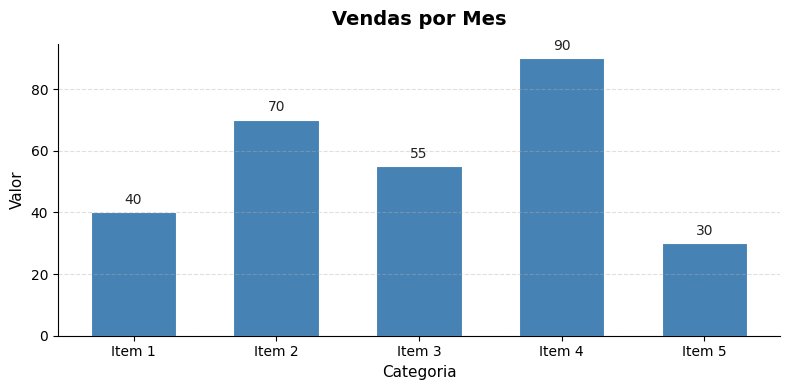

Grafico 1 gerado com sucesso!
  Tipo  : BARRA
  Dados : [40, 70, 55, 90, 30]
  Titulo: 'Vendas por Mes'



In [8]:
interpretar('GRAFICO BARRA DADOS(40, 70, 55, 90, 30) TITULO "Vendas por Mes"')

PROGRAMA NA DSL:
GRAFICO LINHA DADOS(10, 25, 20, 40, 35, 50)

[1] LEXICO    : 16 token(s) identificado(s).
[2] SINTATICO : 1 comando(s) reconhecido(s).
Analise semantica: APROVADA — nenhum erro encontrado.

[4] INTERPRETADOR: gerando grafico(s)...



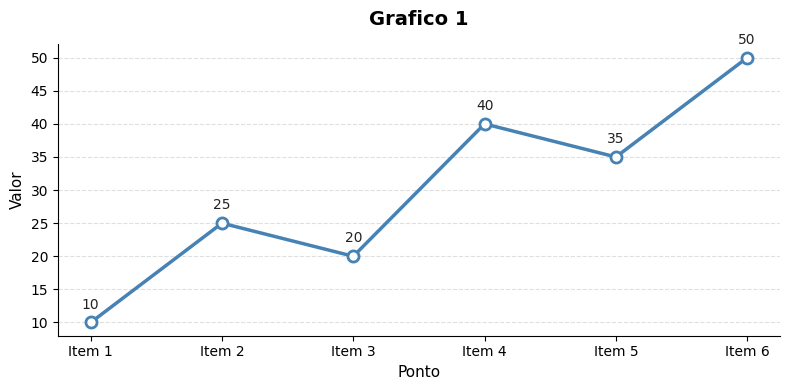

Grafico 1 gerado com sucesso!
  Tipo  : LINHA
  Dados : [10, 25, 20, 40, 35, 50]
  Titulo: 'Grafico 1'



In [9]:
interpretar('GRAFICO LINHA DADOS(10, 25, 20, 40, 35, 50)')

PROGRAMA NA DSL:
GRAFICO BARRA DADOS(100, 200, 150, 80) TITULO "Trimestre 1" GRAFICO LINHA DADOS(5, 15, 10, 20, 25) TITULO "Tendencia Anual"

[1] LEXICO    : 30 token(s) identificado(s).
[2] SINTATICO : 2 comando(s) reconhecido(s).
Analise semantica: APROVADA — nenhum erro encontrado.

[4] INTERPRETADOR: gerando grafico(s)...



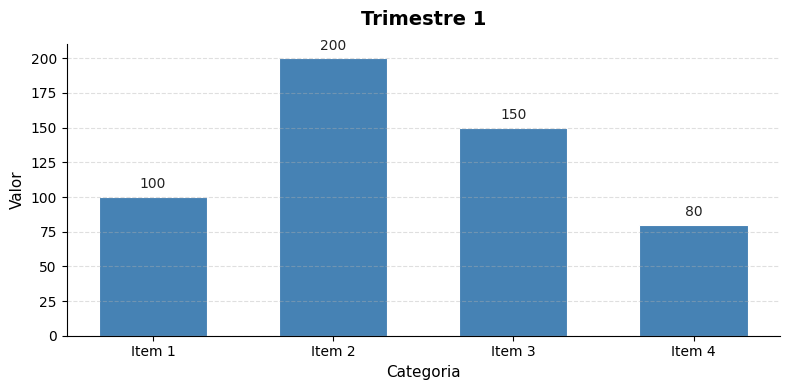

Grafico 1 gerado com sucesso!
  Tipo  : BARRA
  Dados : [100, 200, 150, 80]
  Titulo: 'Trimestre 1'



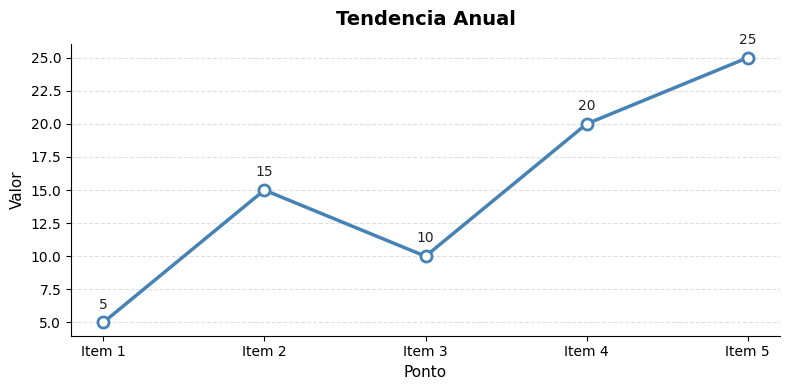

Grafico 2 gerado com sucesso!
  Tipo  : LINHA
  Dados : [5, 15, 10, 20, 25]
  Titulo: 'Tendencia Anual'



In [10]:
interpretar(
    'GRAFICO BARRA DADOS(100, 200, 150, 80) TITULO "Trimestre 1" '
    'GRAFICO LINHA DADOS(5, 15, 10, 20, 25) TITULO "Tendencia Anual"'
)

In [ ]:
# ERRO 1 — Semantico: valor negativo

interpretar('GRAFICO BARRA DADOS(10, -5, 20)')

PROGRAMA NA DSL:
GRAFICO BARRA DADOS(10, -5, 20)

[ERRO LEXICO]    Caractere desconhecido: '-'


In [ ]:
# ERRO 2 — Sintatico: tipo de grafico inexistente

interpretar('GRAFICO PIZZA DADOS(10, 20, 30)')

PROGRAMA NA DSL:
GRAFICO PIZZA DADOS(10, 20, 30)

[1] LEXICO    : 10 token(s) identificado(s).

[ERRO SINTATICO] Tipo de grafico invalido: 'PIZZA'. Use BARRA ou LINHA.


In [ ]:
# ERRO 3 — Semantico: titulo vazio

interpretar('GRAFICO BARRA DADOS(10, 20) TITULO "   "')

PROGRAMA NA DSL:
GRAFICO BARRA DADOS(10, 20) TITULO "   "

[1] LEXICO    : 10 token(s) identificado(s).
[2] SINTATICO : 1 comando(s) reconhecido(s).

[ERRO SEMANTICO] Grafico 1 (BARRA): TITULO nao pode ser vazio ou conter apenas espacos.


PROGRAMA NA DSL:
GRAFICO BARRA DADOS(30, 50, 45, 80, 65) TITULO "Meu Grafico"

[1] LEXICO    : 16 token(s) identificado(s).
[2] SINTATICO : 1 comando(s) reconhecido(s).
Analise semantica: APROVADA — nenhum erro encontrado.

[4] INTERPRETADOR: gerando grafico(s)...



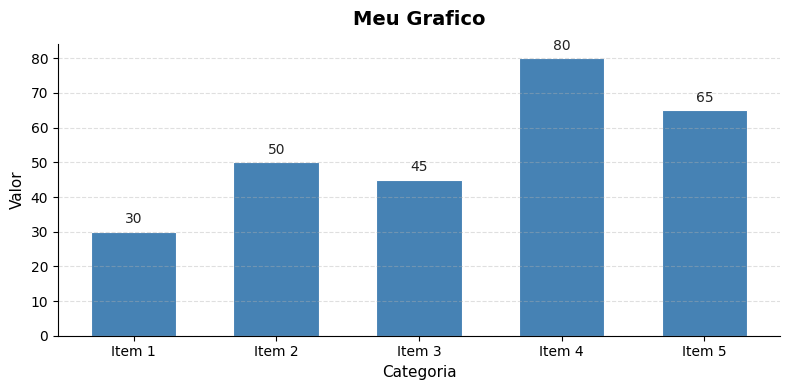

Grafico 1 gerado com sucesso!
  Tipo  : BARRA
  Dados : [30, 50, 45, 80, 65]
  Titulo: 'Meu Grafico'



In [ ]:
meu_programa = """
GRAFICO BARRA DADOS(30, 50, 45, 80, 65) TITULO "Meu Grafico"
"""

interpretar(meu_programa)

PROGRAMA NA DSL:
GRAFICO LINHA DADOS(40, 70, 55, 90, 30, 60, 70, 90000, 2, 1) TITULO "Testinho"

[1] LEXICO    : 26 token(s) identificado(s).
[2] SINTATICO : 1 comando(s) reconhecido(s).
Analise semantica: APROVADA — nenhum erro encontrado.

[4] INTERPRETADOR: gerando grafico(s)...



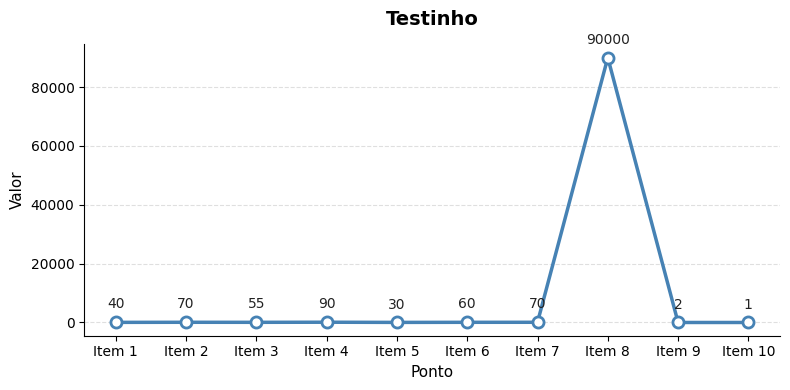

Grafico 1 gerado com sucesso!
  Tipo  : LINHA
  Dados : [40, 70, 55, 90, 30, 60, 70, 90000, 2, 1]
  Titulo: 'Testinho'



In [16]:
interpretar('GRAFICO LINHA DADOS(40, 70, 55, 90, 30, 60, 70, 90000, 2, 1) TITULO "Testinho"')